# Insurance Claim Prediction

###### A machine-learning project to predict insurance-related customer outcomes and support data-driven marketing decisions.

##### Problem Statement-
###### Task 1: Create a predictive model to help the insurance marketing team identify potential customers.
###### Task 2: Provide suggestions to improve customer conversion through targeted marketing.

##### Business Objective
###### Identify potential customers.
###### Improve marketing efficiency.
###### Reduce unnecessary marketing costs.
###### Support targeted customer communication.


##### Dataset Description

###### The dataset contains 595,212 observations and 59 columns, including numerical, categorical and binary features. 
###### The target variable is highly imbalanced, with approximately 96.36% Class 0 and 3.64% Class 1.

### Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.shape

(595212, 59)

In [4]:
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [6]:
df.isnull().sum().sum()

0

In [7]:
df.duplicated().sum()

0

In [8]:
df['target'].value_counts()

target
0    573518
1     21694
Name: count, dtype: int64

In [9]:
df['target'].value_counts(normalize=True)*100

target
0    96.355248
1     3.644752
Name: proportion, dtype: float64

In [10]:
# The id column is an identifier, not a meaningful predictive feature.
# so exclude it
x=df.drop(['target','id'],axis=1)
y=df['target']

print("x shape:",x.shape)

x shape: (595212, 57)


##### As per instruction EDA part is not done.

### Separate x and y

In [11]:
### Train-Test Split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("x_train:",x_train.shape)
print("x_test:",x_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)


x_train: (476169, 57)
x_test: (119043, 57)
y_train: (476169,)
y_test: (119043,)


### Preprocessing

In [12]:
cat_cols = [col for col in x.columns if '_cat' in col]
bin_cols = [col for col in x.columns if '_bin' in col]
num_cols = [col for col in x.columns if col not in cat_cols + bin_cols]

print("Categorical columns:", len(cat_cols))
print("Binary columns:", len(bin_cols))
print("Numerical columns:", len(num_cols))

Categorical columns: 14
Binary columns: 17
Numerical columns: 26


In [13]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

###### cat → One-Hot Encodes the 14 categorical columns
###### num → Standardizes the 26 numerical columns
###### remainder='passthrough' → keeps the 17 binary columns unchanged.
###### So, not scaling the binary 0/1 variables,

In [16]:
# fitting the preprocessing only on training data
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)
# fit_transform() → only X_train
#transform() → X_test

In [17]:
print("x_train_processed shape:", x_train_processed.shape)
print("x_test_processed shape:", x_test_processed.shape)

x_train_processed shape: (476169, 227)
x_test_processed shape: (119043, 227)


In [18]:
# The increase from 57 → 227 is expected because the 14 categorical columns were expanded into multiple one-hot encoded columns.

In [19]:
# Checking that there are no missing values in processed data
print("Missing values in x_train_processed:", np.isnan(x_train_processed.data).sum())
print("Missing values in x_test_processed:", np.isnan(x_test_processed.data).sum())

Missing values in x_train_processed: 0
Missing values in x_test_processed: 0


### Model Building

###### in this section,different classification models are trained and evaluated to predict the insurance claim outcome.
###### The first model used is Logistic Regrassion,it is used as a baseline classification model.
###### It provides a simple and interpretable benchmark for comparing other classification algorithms.

#### Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [22]:
logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    x_train_processed,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [23]:
y_pred_logistic = logistic_model.predict(x_test_processed)

y_prob_logistic = logistic_model.predict_proba(
    x_test_processed
)[:, 1]

In [24]:
print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_logistic, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_logistic, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    zero_division=0
))

Logistic Regression Results
----------------------------------------
Accuracy : 0.6256226741597574
Precision: 0.053953962833192884
Recall   : 0.5607282784051625
F1 Score : 0.09843626727085146
ROC-AUC  : 0.6316962680475149

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.63      0.76    114704
           1       0.05      0.56      0.10      4339

    accuracy                           0.63    119043
   macro avg       0.51      0.59      0.43    119043
weighted avg       0.94      0.63      0.74    119043



### SVM Support Vector Machine

###### Support Vector Machine is used to find a decision boundary that separates the classes.
###### Linear SVM is used here because the dataset contains a large number of observations and porcessed features.
###### Class weighing is applied to handle the imbalance in the target variable.

In [26]:
from sklearn.svm import LinearSVC

In [27]:
svm_model = LinearSVC(
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
    random_state=42
)

svm_model.fit(
    x_train_processed,
    y_train
)

LinearSVC(class_weight='balanced', random_state=42)

In [28]:
y_pred_svm = svm_model.predict(
    x_test_processed
)

In [29]:
y_score_svm = svm_model.decision_function(
    x_test_processed
)

In [30]:
print("Linear SVM Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_svm, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_svm, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_score_svm))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

Linear SVM Results
----------------------------------------
Accuracy : 0.6271599338054317
Precision: 0.054014923710880944
Recall   : 0.5588845356072828
F1 Score : 0.09850916033635293
ROC-AUC  : 0.6317204231291991

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.63      0.76    114704
           1       0.05      0.56      0.10      4339

    accuracy                           0.63    119043
   macro avg       0.51      0.59      0.43    119043
weighted avg       0.94      0.63      0.74    119043



### Random Forest

###### Random Forest is an ensemble classification algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.

###### A balanced class weight was used because the insurance dataset has a highly imbalanced target variable.

In [31]:
from sklearn.ensemble import RandomForestClassifier


In [32]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

random_forest_model.fit(
    x_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10, n_jobs=-1,
                       random_state=42)

In [33]:
y_pred_rf = random_forest_model.predict(
    x_test_processed
)

y_prob_rf = random_forest_model.predict_proba(
    x_test_processed
)[:, 1]

In [34]:
print("Random Forest Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Random Forest Results
----------------------------------------
Accuracy : 0.766874154717203
Precision: 0.059790170345579666
Recall   : 0.36644388107858955
F1 Score : 0.10280615543773439
ROC-AUC  : 0.622987071168337

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.87    114704
           1       0.06      0.37      0.10      4339

    accuracy                           0.77    119043
   macro avg       0.52      0.57      0.48    119043
weighted avg       0.94      0.77      0.84    119043



### Decision Tree

###### Decision Tree is a supervised classification algorithm that makes predictions by splitting the data into smaller groups based on feature values.
###### A balanced class weight is used because the insurance dataset has an imbalanced target variable.

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

decision_tree_model.fit(
    x_train_processed,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [38]:
y_pred_dt = decision_tree_model.predict(
    x_test_processed
)

y_prob_dt = decision_tree_model.predict_proba(
    x_test_processed
)[:, 1]

In [39]:
print("Decision Tree Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_dt, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        zero_division=0
    )
)

Decision Tree Results
----------------------------------------
Accuracy : 0.6165671228043648
Precision: 0.04906113537117904
Recall   : 0.5178612583544595
F1 Score : 0.089630826302878
ROC-AUC  : 0.5884359533574737

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.62      0.76    114704
           1       0.05      0.52      0.09      4339

    accuracy                           0.62    119043
   macro avg       0.51      0.57      0.42    119043
weighted avg       0.94      0.62      0.73    119043



### KNN

###### KNN is a supervised classification algorithm that classifies a new observation based on the classes of its nearest neighboring observations.

###### A smaller stratified sample was used for KNN because the full dataset is large and KNN is computationally expensive.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Take a smaller, stratified sample for KNN
x_train_knn, _, y_train_knn, _ = train_test_split(
    x_train_processed,
    y_train,
    train_size=50000,
    random_state=42,
    stratify=y_train
)

x_test_knn, _, y_test_knn, _ = train_test_split(
    x_test_processed,
    y_test,
    train_size=20000,
    random_state=42,
    stratify=y_test
)

print("KNN training shape:", x_train_knn.shape)
print("KNN testing shape:", x_test_knn.shape)

KNN training shape: (50000, 227)
KNN testing shape: (20000, 227)


In [41]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(
    x_train_knn,
    y_train_knn
)

print("KNN training completed")

KNN training completed


In [42]:
y_pred_knn = knn_model.predict(
    x_test_knn
)

y_prob_knn = knn_model.predict_proba(
    x_test_knn
)[:, 1]

print("KNN prediction completed")

KNN prediction completed


In [43]:
print("K-Nearest Neighbors Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test_knn, y_pred_knn))
print("Precision:", precision_score(y_test_knn, y_pred_knn, zero_division=0))
print("Recall   :", recall_score(y_test_knn, y_pred_knn, zero_division=0))
print("F1 Score :", f1_score(y_test_knn, y_pred_knn, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test_knn, y_prob_knn))

print("\nClassification Report:")
print(classification_report(
    y_test_knn,
    y_pred_knn,
    zero_division=0
))

K-Nearest Neighbors Results
----------------------------------------
Accuracy : 0.96285
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5136705835808498

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     19271
           1       0.00      0.00      0.00       729

    accuracy                           0.96     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.93      0.96      0.95     20000



#### Gradient Boosting model

###### Gradient Boosting is an ensemble classification algorithm that builds models sequentially, with each new model focusing on correcting the errors made by previous models.

###### It was used to capture complex patterns in the insurance dataset and improve the identification of minority-class customers.

In [48]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Calculate balanced sample weights
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

print("Gradient Boosting training shape:", x_train_processed.shape)
print("Gradient Boosting testing shape:", x_test_processed.shape)

Gradient Boosting training shape: (476169, 227)
Gradient Boosting testing shape: (119043, 227)


In [50]:
gb_model.fit(
    x_train_processed,
    y_train,
    sample_weight=sample_weights
)

GradientBoostingClassifier(max_depth=2, random_state=42)

In [52]:
y_pred_gb = gb_model.predict(x_test_processed)
y_prob_gb = gb_model.predict_proba(x_test_processed)[:, 1]

In [53]:
y_pred_gb
y_prob_gb

array([0.51289601, 0.51662298, 0.33143289, ..., 0.52932457, 0.42844889,
       0.43374848])

In [54]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Linear SVM',
        'KNN',
        'Gradient Boosting'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test_knn, y_pred_knn),
        accuracy_score(y_test, y_pred_gb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_logistic, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_svm, zero_division=0),
        precision_score(y_test_knn, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_gb, zero_division=0)
    ],

    'Recall': [
        recall_score(y_test, y_pred_logistic, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_svm, zero_division=0),
        recall_score(y_test_knn, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_gb, zero_division=0)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_logistic, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_svm, zero_division=0),
        f1_score(y_test_knn, y_pred_knn, zero_division=0),
        f1_score(y_test, y_pred_gb, zero_division=0)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_score_svm),
        roc_auc_score(y_test_knn, y_prob_knn),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.625623,0.053954,0.560728,0.098436,0.631696
1,Decision Tree,0.616567,0.049061,0.517861,0.089631,0.588436
2,Random Forest,0.766874,0.059790,0.366444,0.102806,0.622987
3,Linear SVM,0.627160,0.054015,0.558885,0.098509,0.631720
4,KNN,0.962850,0.000000,0.000000,0.000000,0.513671
5,Gradient Boosting,0.621423,0.054027,0.568564,0.098678,0.635661


### Data Visualization using Matplotlib 

###### Matplotlib is a Python visualization library used to create graphs and charts for analyzing data and comparing model performance.

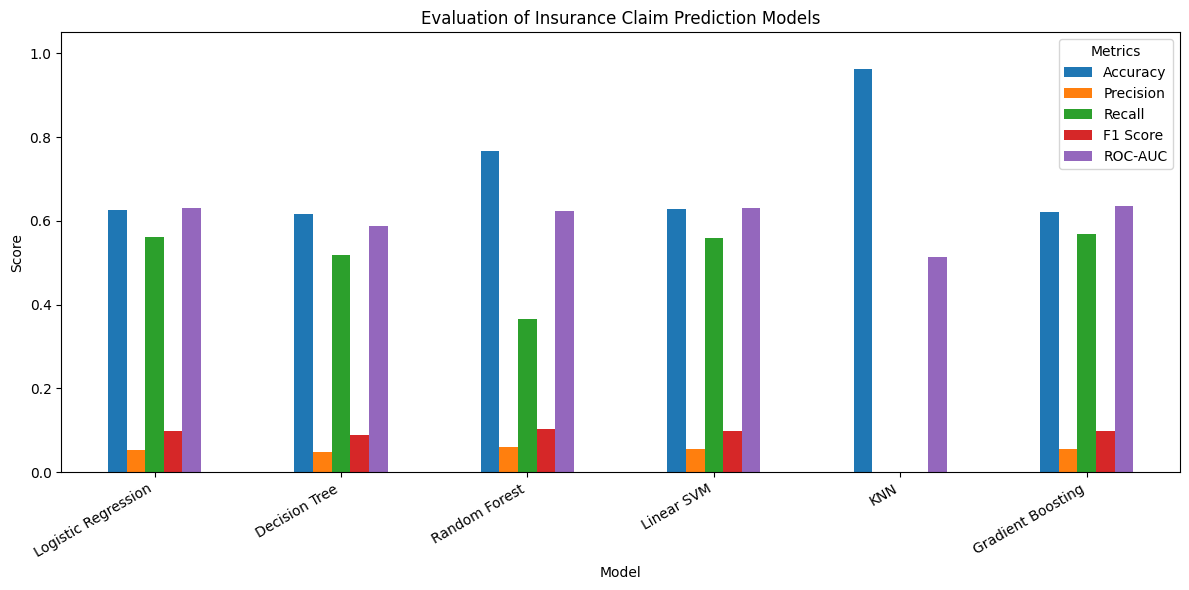

In [55]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

ax = model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Evaluation of Insurance Claim Prediction Models")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [56]:
best_model = model_comparison.loc[
    model_comparison["ROC-AUC"].idxmax()
]

print("Best model by ROC-AUC:", best_model["Model"])
print("ROC-AUC:", round(best_model["ROC-AUC"], 4))

Best model by ROC-AUC: Gradient Boosting
ROC-AUC: 0.6357


### Model Selection

###### Six ML models are are evaluated.
###### Since the insurance dataset is highly imbalanced, accuracy alone was not considered sufficient for model selection.
###### Precision, recall, F1-score and ROC-AUC were also evaluated, with particular emphasis on minority-class recall.
###### Random Forest achieved the highest accuracy among the models evaluated on the full test dataset at 76.69%
###### However, its minority-class recall was only 36.64%. KNN achieved an accuracy of 96.29%, 
###### But it failed to identify any minority-class observations, resulting in zero precision, recall and F1-score.

###### Gradient Boosting achieved the highest minority-class recall of 56.86% and the highest ROC-AUC of 63.57% among the six models. 
###### It also achieved an F1-score of 9.87%. 
###### Therefore, considering the objective of identifying potential customers and the severe class imbalance, Gradient Boosting was selected as the best candidate model among the evaluated models.

#### Production Recommendation

###### Gradient Boosting is recommended as the best candidate model for production among the models evaluated. 
###### However, its relatively low precision indicates a high number of false-positive predictions. 
###### Therefore, probability-threshold optimization, further feature engineering, and business-cost analysis should be performed before final production deployment.

#### Suggestions to the Insurance Marketing Team

###### The objective is to use the model predictions to identify customers 
###### who are more likely to purchase the insurance product and target them with suitable marketing strategie

##### Recommended Marketing Strategies-

###### 1. Target high-probability customers first.
###### 2. Personlized offers.
###### 3. Targeted communication.
###### 4. Customer segmentation.
###### 5. Follow up campaigns.
###### 6. Optimize marketing cost.


###### The insurance marketing team should use the model as a customer-prioritization tool rather than contacting every predicted customer. 
###### Customers can be ranked according to their predicted purchase probability, with marketing resources concentrated on the highest-probability segments. 
###### The effectiveness of the campaigns should then be measured using conversion rate, campaign cost, and revenue generated. 
###### This approach can help reduce unnecessary marketing expenditure while improving customer targeting and potential sales.

### Model Saving using Joblib

In [63]:
import joblib

joblib.dump(gb_model, "gradient_boosting_model.pkl")

print("Gradient Boosting model saved successfully.")

Gradient Boosting model saved successfully.
